# Business Objective

## The objective of this project is to build a machine learning model that predicts whether a customer will generate revenue during an online shopping session.

## Such predictions help businesses:

1. Target high-value customers
2. Personalize marketing campaigns
3. Reduce marketing costs
4. Improve conversion rates

## Machine Learning Workflow

1. Load cleaned dataset
2. Split train/test
3. Feature Scaling
4. Handle Class Imbalance
5. Train Baseline Models
6. Hyperparameter Tuning
7. Model Evaluation
8. Feature Importance
9. Final Model Selection
10. Business Recommendations

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('online_shoppers_cleaned.csv')

In [3]:
df.head()

,administrative,administrative_duration,informational,informational_duration,productrelated,productrelated_duration,bouncerates,exitrates,pagevalues,specialday,month,operatingsystems,browser,region,traffictype,visitortype,weekend,revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


In [4]:
df.shape

(12205, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   administrative           12205 non-null  int64  
 1   administrative_duration  12205 non-null  float64
 2   informational            12205 non-null  int64  
 3   informational_duration   12205 non-null  float64
 4   productrelated           12205 non-null  int64  
 5   productrelated_duration  12205 non-null  float64
 6   bouncerates              12205 non-null  float64
 7   exitrates                12205 non-null  float64
 8   pagevalues               12205 non-null  float64
 9   specialday               12205 non-null  float64
 10  month                    12205 non-null  object 
 11  operatingsystems         12205 non-null  int64  
 12  browser                  12205 non-null  int64  
 13  region                   12205 non-null  int64  
 14  traffictype           

# Encoding Categorical Values

In [6]:
df = pd.get_dummies(
    df,
    columns=['month', 'visitortype'],
    drop_first=True
)


In [7]:
df.head(5)

,administrative,administrative_duration,informational,informational_duration,productrelated,productrelated_duration,bouncerates,exitrates,pagevalues,specialday,...,month_Feb,month_Jul,month_June,month_Mar,month_May,month_Nov,month_Oct,month_Sep,visitortype_Other,visitortype_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   administrative                 12205 non-null  int64  
 1   administrative_duration        12205 non-null  float64
 2   informational                  12205 non-null  int64  
 3   informational_duration         12205 non-null  float64
 4   productrelated                 12205 non-null  int64  
 5   productrelated_duration        12205 non-null  float64
 6   bouncerates                    12205 non-null  float64
 7   exitrates                      12205 non-null  float64
 8   pagevalues                     12205 non-null  float64
 9   specialday                     12205 non-null  float64
 10  operatingsystems               12205 non-null  int64  
 11  browser                        12205 non-null  int64  
 12  region                         12205 non-null 

# Feature and Target

In [9]:
X = df.drop('revenue', axis=1)
y = df['revenue']

In [10]:
print(X.shape)
print(y.shape)

(12205, 26)
(12205,)


# Train Test Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print('Training Set : ', X_train.shape)
print('Testing Set : ',X_test.shape)

Training Set :  (9764, 26)
Testing Set :  (2441, 26)


# Feature Scaling (For Logistic Regression)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Why Scaling?
1. Algorithms like Logistic Regression depend on feature magnitudes.
2. Scaling helps gradient optimization converge faster and improves stability.
3. Tree-based models (Random Forest, XGBoost) do not require scaling.

# Handling Class Imbalance (With SMOTE)

In [14]:
y_train.value_counts()

revenue
0    8238
1    1526
Name: count, dtype: int64

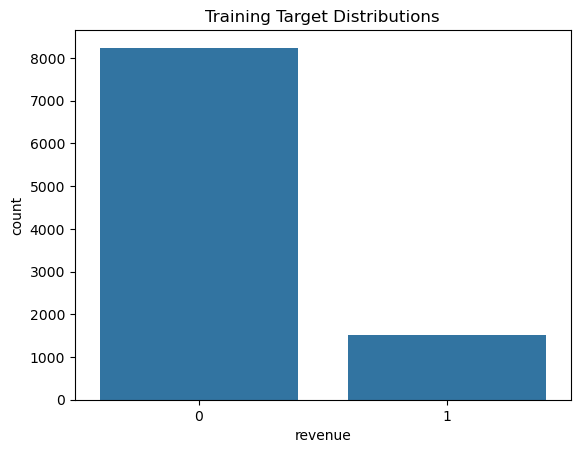

In [15]:
sns.countplot(
    x=y_train,
    )
plt.title('Training Target Distributions')
plt.show()

The Y_train split is highly imbalanced

In [16]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote , y_train_smote = smote.fit_resample(X_train_scaled, y_train)

## Why SMOTE?

1. The target variable is highly imbalanced.
2. Without balancing, the model would mostly predict the majority class.
3. SMOTE creates synthetic minority samples to improve recall and F1-score.

In [17]:
y_train_smote.value_counts()

revenue
1    8238
0    8238
Name: count, dtype: int64

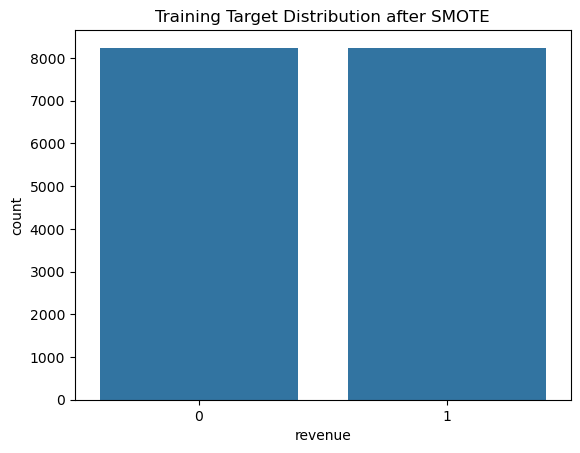

In [18]:
sns.countplot(x=y_train_smote)
plt.title('Training Target Distribution after SMOTE')
plt.show()

# MODEL 1 : Baseline Logistic Regression

## Why Logistic Regression?
1. Acts as a baseline model.
2. Simple
3. Fast
4. Interpretable
5. Good benchmark for comparison

In [19]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]

In [30]:
from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        classification_report,
        confusion_matrix,
        roc_auc_score,
        RocCurveDisplay
)

In [31]:
def evaluate_model(model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(5,4))
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(model.__class__.__name__)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.show()

LogisticRegression
Accuracy : 0.8521097910692339
Precision: 0.5183887915936952
Recall   : 0.774869109947644
F1 Score : 0.621196222455404
ROC AUC  : 0.9106527593072427

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2059
           1       0.52      0.77      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.82      0.76      2441
weighted avg       0.89      0.85      0.86      2441



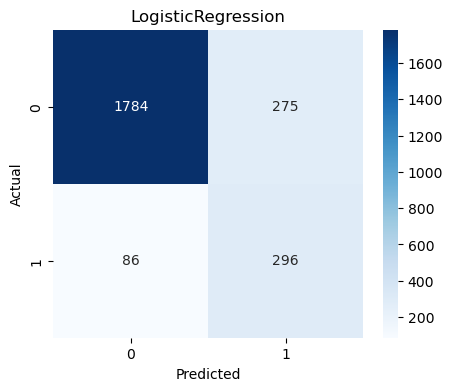

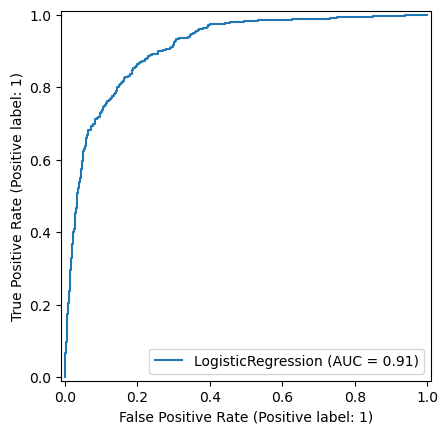

In [32]:
evaluate_model(lr, X_test_scaled, y_test)

Observations
1. The Logistic Regression model achieved an accuracy of 85.21%, providing a strong baseline for the classification task.
2. The model achieved a precision of 51.84%, indicating that about half of the predicted purchases were actual purchases.
3. A recall of 77.49% shows that the model successfully identified most customers who made a purchase.
4. The F1-score of 62.12% indicates a reasonable balance between precision and recall.
5. The ROC-AUC score of 91.07% demonstrates excellent ability to distinguish between purchasing and non-purchasing customers.
6. The model performs better in predicting non-purchasing customers (Class 0) than purchasing customers (Class 1), which is expected in an imbalanced dataset.
7. Overall, Logistic Regression serves as a strong baseline model, and its performance will be compared with tree-based models such as Random Forest and XGBoost.

# Model 2 : Random Forest Calssifier

## Random Forest is an ensemble learning algorithm.
## Advantages
1. Handles non-linear relationships
2. Resistant to overfitting
3. Provides feature importance
4. Works well with tabular data

In [33]:
X_train_smote_rf, y_train_smote_rf = smote.fit_resample(X_train, y_train)

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote_rf, y_train_smote_rf)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


RandomForestClassifier
Accuracy : 0.891028267103646
Precision: 0.632420091324201
Recall   : 0.725130890052356
F1 Score : 0.675609756097561
ROC AUC  : 0.9229604926907536

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      2059
           1       0.63      0.73      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.82      0.81      2441
weighted avg       0.90      0.89      0.89      2441



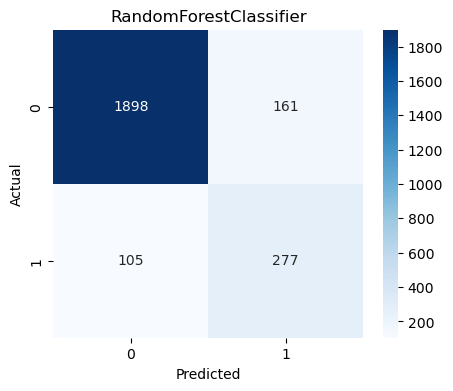

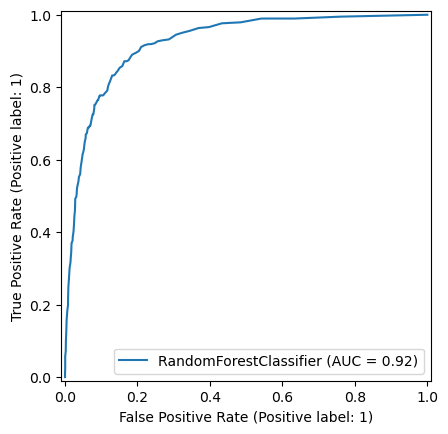

In [35]:
evaluate_model(rf, X_test, y_test)

Observation:
1. The Random Forest model achieved an accuracy of 89.10%, outperforming the Logistic Regression baseline.
2. The precision increased to 63.24%, indicating fewer false positive purchase predictions.
3. The model achieved a recall of 72.51%, successfully identifying a large proportion of purchasing customers.
4. The F1-score of 67.56% indicates a better balance between precision and recall than Logistic Regression.
5. The ROC-AUC score of 92.30% demonstrates excellent ability to distinguish between purchasing and non-purchasing customers.
6. Overall, the Random Forest model provides better overall predictive performance and is a stronger candidate for the final model.

# Model 3 : Random Forest Classifier (HyperParamter Tuning)

## Why Hyperparameter Tuning?
1. Default parameters rarely produce optimal performance.
2. GridSearchCV searches multiple parameter combinations using cross-validation and selects the best-performing model.

In [36]:
from sklearn.model_selection import RandomizedSearchCV

In [37]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [39]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,          
    scoring='f1',       
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [41]:
rf_random.fit(X_train_smote_rf, y_train_smote_rf)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
print(rf_random.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [43]:
best_rf = rf_random.best_estimator_

RandomForestClassifier
Accuracy : 0.896763621466612
Precision: 0.6484018264840182
Recall   : 0.743455497382199
F1 Score : 0.6926829268292682
ROC AUC  : 0.9249165329583567

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2059
           1       0.65      0.74      0.69       382

    accuracy                           0.90      2441
   macro avg       0.80      0.83      0.82      2441
weighted avg       0.90      0.90      0.90      2441



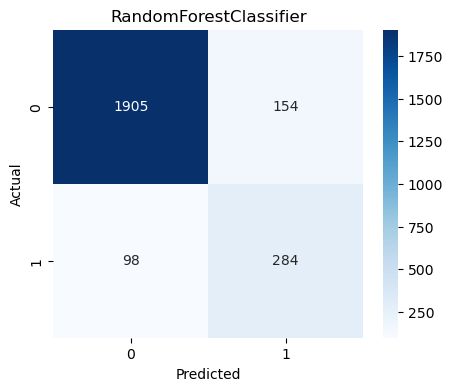

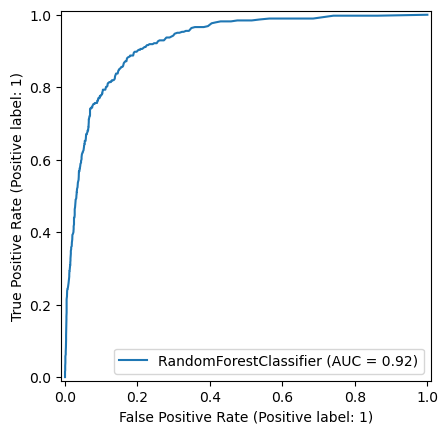

In [44]:
evaluate_model(best_rf, X_test, y_test)

## Interpretation
1. True Positives = correctly predicted revenue sessions
2. False Positives = predicted revenue but actually no revenue
3. False Negatives = missed revenue opportunities
4. True Negatives = correctly predicted no revenue
5. The ROC curve illustrates the trade-off between sensitivity and specificity.
6. Higher AUC indicates better class separation.
7. An AUC closer to 1 suggests excellent predictive performance.

Observations:
1. The tuned Random Forest achieved an accuracy of 89.68%, showing a slight improvement over the baseline model.
2. Precision increased to 64.84%, indicating fewer false positive predictions.
3. Recall improved to 74.35%, allowing the model to identify more purchasing customers.
4. The F1-score improved to 69.27%, demonstrating a better balance between precision and recall.
5. The ROC-AUC score of 92.49% indicates excellent discrimination between purchasing and non-purchasing customers.
6. Overall, hyperparameter tuning resulted in a modest but consistent improvement across all evaluation metrics, making the tuned Random Forest the     better-performing model.

## Feature Importance

In [62]:
feature_importance = pd.DataFrame({
    'Feature' : X_train_smote_rf.columns,
    'Importance' : best_rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

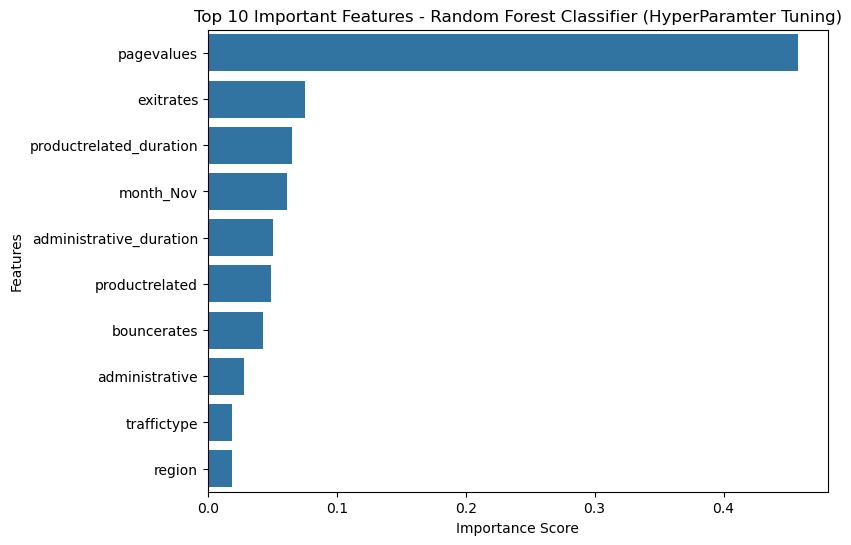

In [63]:
plt.figure(figsize=(8,6))
sns.barplot(
    data= feature_importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Important Features - Random Forest Classifier (HyperParamter Tuning)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Top Important Features
1. Page Values
2. Exit Rates
3. Bounce Rates
4. Product Related Duration
5. These features contribute most towards revenue prediction.

# Model 4 : XGBOOST

## Why XGBoost?
1. Uses gradient boosting.
2. Sequentially improves weak learners.
3. Generally produces better accuracy than Random Forest.

In [53]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_smote_rf, y_train_smote_rf)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


XGBClassifier
Accuracy : 0.8897992625972961
Precision: 0.6335697399527187
Recall   : 0.7015706806282722
F1 Score : 0.6658385093167701
ROC AUC  : 0.9221283650630994

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2059
           1       0.63      0.70      0.67       382

    accuracy                           0.89      2441
   macro avg       0.79      0.81      0.80      2441
weighted avg       0.90      0.89      0.89      2441



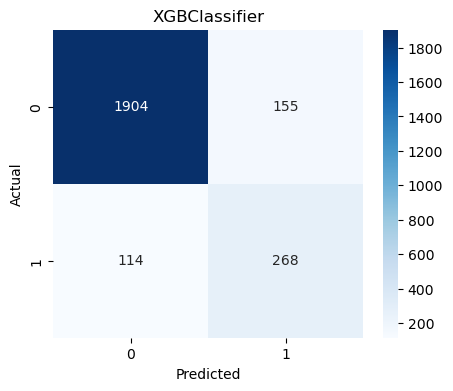

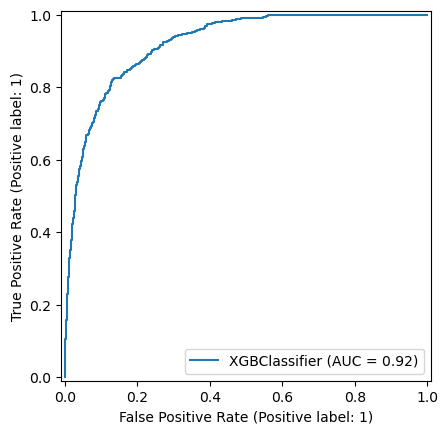

In [54]:
evaluate_model(xgb, X_test, y_test)

Observation:
1. The baseline XGBoost model achieved an accuracy of 88.98%, demonstrating strong predictive performance.
2. The model achieved a precision of 63.36%, indicating good identification of purchasing customers with relatively few false positives.
3. A recall of 70.16% shows that the model successfully identified a majority of purchasing customers.
4. The F1-score of 66.58% reflects a good balance between precision and recall.
5. The ROC-AUC score of 92.21% indicates excellent ability to distinguish between purchasing and non-purchasing customers.
6. Compared with the baseline Random Forest, XGBoost achieved similar performance but slightly lower recall, F1-score, and ROC-AUC.

# Model 5 : XGBoost (Hyperparamter Tuning)

In [55]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

In [56]:
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [58]:
xgb_random.fit(X_train_smote_rf, y_train_smote_rf)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [59]:
print(xgb_random.best_params_)

{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [60]:
best_xgb = xgb_random.best_estimator_

XGBClassifier
Accuracy : 0.8857025809094633
Precision: 0.62004662004662
Recall   : 0.6963350785340314
F1 Score : 0.655980271270037
ROC AUC  : 0.9291782469505604

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2059
           1       0.62      0.70      0.66       382

    accuracy                           0.89      2441
   macro avg       0.78      0.81      0.79      2441
weighted avg       0.89      0.89      0.89      2441



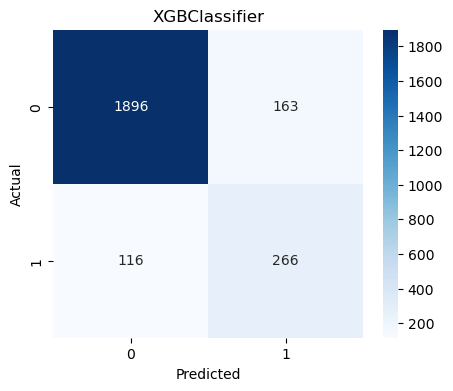

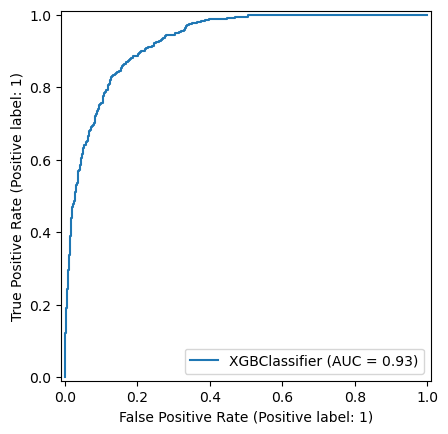

In [61]:
evaluate_model(best_xgb, X_test, y_test)

Observation:
1. The tuned XGBoost model achieved an accuracy of 88.57%, slightly lower than the baseline model.
2. The precision (62.00%), recall (69.63%), and F1-score (65.60%) decreased marginally after tuning.
3. The ROC-AUC improved to 92.92%, indicating slightly better ranking ability despite lower classification performance.
4. Overall, the baseline XGBoost model generalized better on the test dataset than the tuned version.

In [66]:
feature_importances = pd.DataFrame({
    'Feature' : X_train_smote_rf.columns,
    'Importance': best_xgb.feature_importances_
})
feature_importances = feature_importances.sort_values(
    by='Importance',
    ascending=False
)

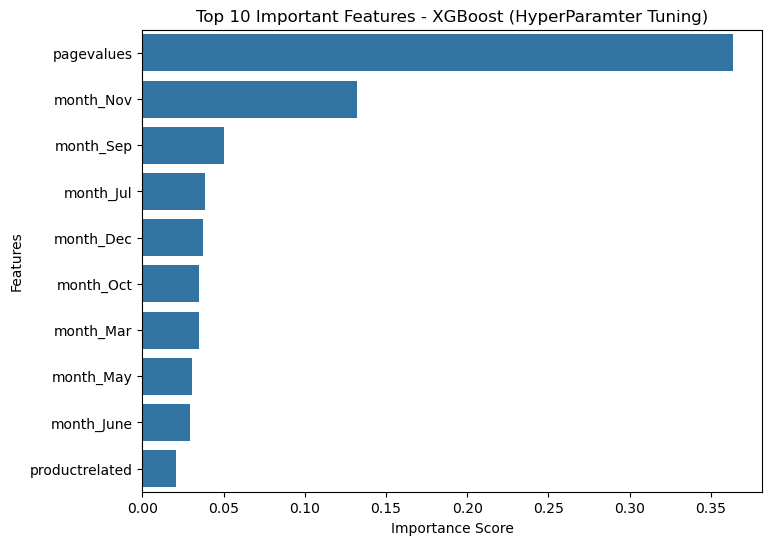

In [68]:
plt.figure(figsize=(8,6))
sns.barplot(
    data = feature_importances.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Important Features - XGBoost (HyperParamter Tuning)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Feature Importance - Tuned XGBOOST Classifier
1. PageValues is by far the most influential feature, contributing nearly 37% of the overall importance. This indicates that pages associated with higher commercial value strongly influence purchase decisions.
2. November is the second most important feature. This aligns with seasonal shopping trends such as Black Friday and holiday promotions, where customers are generally more likely to complete purchases.
3. Other month-related variables such as **September, October, December, July, March, May, and June also contribute to the model, suggesting that customer purchasing behaviour varies throughout the year due to seasonal demand.
4. ProductRelated appears among the top predictors, indicating that visitors who spend more time browsing product pages demonstrate stronger purchase intent.
5. Overall, the tuned XGBoost model suggests that both ser engagement (PageValues and ProductRelated) and seasonality (Month features) are the strongest indicators of purchase intention.

In [72]:
# Create Model Comparison Table
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)',
        'Random Forest (Baseline)',
        'Random Forest (Tuned)',
        'XGBoost (Baseline)',
        'XGBoost (Tuned)'
    ],
    
    'Accuracy': [
        0.8521,
        0.8910,
        0.8968,
        0.8898,
        0.8857
    ],
    
    'Precision': [
        0.5184,
        0.6324,
        0.6484,
        0.6336,
        0.6200
    ],
    
    'Recall': [
        0.7749,
        0.7251,
        0.7435,
        0.7016,
        0.6963
    ],
    
    'F1-Score': [
        0.6212,
        0.6756,
        0.6927,
        0.6658,
        0.6560
    ],
    
    'ROC-AUC': [
        0.9107,
        0.9230,
        0.9249,
        0.9221,
        0.9292
    ]
})

# Display table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.8521,0.5184,0.7749,0.6212,0.9107
1,Random Forest (Baseline),0.8910,0.6324,0.7251,0.6756,0.9230
2,Random Forest (Tuned),0.8968,0.6484,0.7435,0.6927,0.9249
3,XGBoost (Baseline),0.8898,0.6336,0.7016,0.6658,0.9221
4,XGBoost (Tuned),0.8857,0.6200,0.6963,0.6560,0.9292


## Final Observations:
Although the tuned XGBoost model achieved the highest ROC-AUC (0.9292), the tuned Random Forest produced the highest F1-score (0.6927) while also achieving the best precision and recall balance. Since the project's objective is to accurately identify potential buyers while minimizing both false positives and false negatives, the tuned Random Forest was selected as the final model.

## Business Recommendations
1. Target visitors with high Page Values.
2. Retarget users with high product interaction.
3. Personalize campaigns using predicted probabilities.
4. Focus promotions on customers likely to convert.
5. Use the model in real-time recommendation systems.